In [77]:
import yfinance as yf
import pandas as pd 
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt 

In [78]:
'''

EACH STRATEGY SHOULD FOLLOW THE FOLLOWING THREE STEPS

1) ACQUIRE THE DATA - SPY

2) DEFINE THE STRATEGY - GOLDEN CROSSOVER

3) TEST THE STRATEGY


'''

'\n\nEACH STRATEGY SHOULD FOLLOW THE FOLLOWING THREE STEPS\n\n1) ACQUIRE THE DATA - SPY\n\n2) DEFINE THE STRATEGY - GOLDEN CROSSOVER\n\n3) TEST THE STRATEGY\n\n\n'

In [79]:
''' 

ENTRY SIGNAL: 50 DAY MA MOVES ABOVE THE 200 DAY MA

EXIT SIGNAL:  50 DAY MA MOVES BELOW THE 200 DAY MA / PRICE DIPS BELOW THE 200 DAY MA

'''

' \n\nENTRY SIGNAL: 50 DAY MA MOVES ABOVE THE 200 DAY MA\n\nEXIT SIGNAL:  50 DAY MA MOVES BELOW THE 200 DAY MA / PRICE DIPS BELOW THE 200 DAY MA\n\n'

In [80]:
# Define global variables
TICKER = "SPY"
FAST = 50
SLOW = 200
LOOKBACK = 10000

In [81]:
# included adjustable time global variable to adjust the data lookback period
START = datetime.today()
END = START - timedelta(365 * 10)

ACQUIRE & PLOT DATA

In [82]:
def load_data(TICKER):
    data = yf.download(TICKER, start=END, end=START)
    data.columns = data.columns.get_level_values(0)
    return pd.DataFrame(data)

In [83]:
df = load_data(TICKER)

[*********************100%***********************]  1 of 1 completed


In [84]:
def add_moving_averages(df):
    df[f"{FAST}"] = df["Close"].rolling(window=SLOW).mean()
    df[f"{SLOW}"] = df["Close"].rolling(window=FAST).mean()
    df = df.dropna()
    return df 

In [85]:
add_moving_averages(df)

Price,Close,High,Low,Open,Volume,50,200
Date,,,,,,,
2017-02-28,204.163589,204.578008,203.775071,204.336263,96961900,187.020698,197.609198
2017-03-01,207.021408,207.487641,205.804038,205.821310,149158200,187.185995,197.856108
2017-03-02,205.717712,206.840110,205.665912,206.831468,70246000,187.336193,198.084559
2017-03-03,205.847229,206.011273,205.251494,205.631384,81974300,187.495237,198.307139
2017-03-06,205.234207,205.588183,204.629830,205.052891,55391500,187.650962,198.502436
...,...,...,...,...,...,...,...
2026-05-04,718.010010,722.119995,714.989990,720.070007,51950600,668.413920,680.087032
2026-05-05,723.770020,725.039978,721.489990,721.770020,36933200,668.921263,680.951803
2026-05-06,733.830017,734.590027,727.820007,728.159973,53288900,669.473005,681.918845


In [86]:
#plot our moving averages with close price
def plot_dataset(df):
    plt.plot(df["Close"], label="Close Price")
    plt.plot(df[f"{FAST}"], label="50 day moving average")
    plt.plot(df[f"{SLOW}"], label="200 day moving average")
    plt.title(f"{TICKER} Closing Price & 50 & 200 Day Moving Averages")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.legend(loc=2)
    plt.grid(True)
    plt.show()

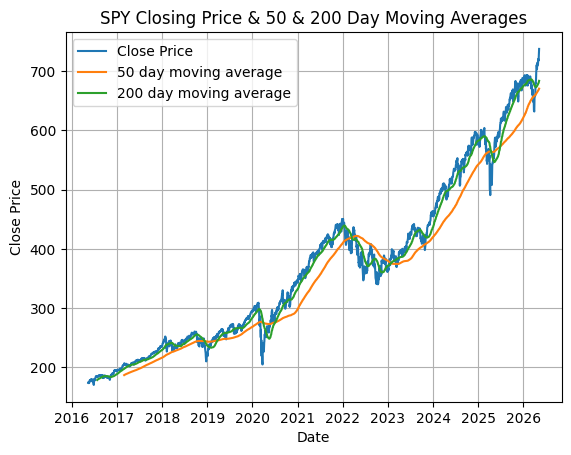

In [87]:
plot_dataset(df)

In [88]:
# Plot a subsection of the past 500 days using the global 'LOOKBACK' variable
def dataset_subset_plot(df):
    subset = df.iloc[-LOOKBACK:, :]
    
    plt.plot(subset["Close"], label="SPY Closing Price")
    plt.plot(subset[f"{SLOW}"], label="50 Day Moving Average")
    plt.plot(subset[f"{FAST}"], label="200 Day Moving Average")
    plt.title("Moving Average Crossovers")
    plt.xlabel("Date")
    plt.ylabel("Closing Price in USD$")
    plt.legend(loc=2)
    plt.grid(True)
    plt.show()

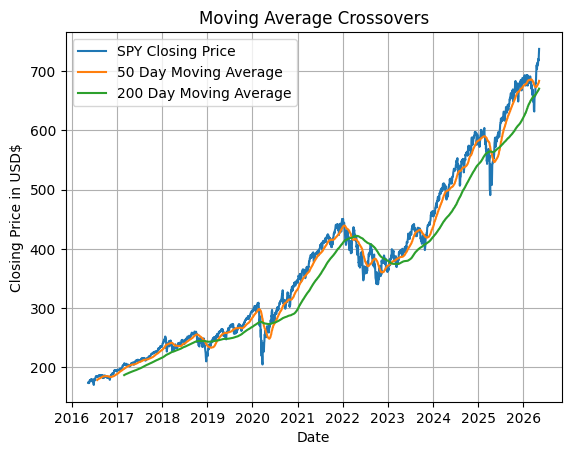

In [89]:
dataset_subset_plot(df)

DEFINE STRATEGY

In [90]:
'''

LONG POSITION: 50 DAY MOVING AVERAGE > 200 DAY MOVING AVERAGE

SHORT POSITION: 50 DAY MOVING AVERAGE < 200 DAY MOVING AVERAGE 

'''

'\n\nLONG POSITION: 50 DAY MOVING AVERAGE > 200 DAY MOVING AVERAGE\n\nSHORT POSITION: 50 DAY MOVING AVERAGE < 200 DAY MOVING AVERAGE \n\n'

In [91]:
def add_strategy(df, SLOW, FAST):
    df["Strategy"] = np.where(df[f"{SLOW}"] > df[f"{FAST}"], 1, -1)
    df["Strategy"] = df["Strategy"].shift(1)
    return df.dropna()

In [92]:
df = add_strategy(df, SLOW, FAST)

In [93]:
df

Price,Close,High,Low,Open,Volume,50,200,Strategy
Date,,,,,,,,
2017-02-28,204.163589,204.578008,203.775071,204.336263,96961900,187.020698,197.609198,-1.0
2017-03-01,207.021408,207.487641,205.804038,205.821310,149158200,187.185995,197.856108,1.0
2017-03-02,205.717712,206.840110,205.665912,206.831468,70246000,187.336193,198.084559,1.0
2017-03-03,205.847229,206.011273,205.251494,205.631384,81974300,187.495237,198.307139,1.0
2017-03-06,205.234207,205.588183,204.629830,205.052891,55391500,187.650962,198.502436,1.0
...,...,...,...,...,...,...,...,...
2026-05-04,718.010010,722.119995,714.989990,720.070007,51950600,668.413920,680.087032,1.0
2026-05-05,723.770020,725.039978,721.489990,721.770020,36933200,668.921263,680.951803,1.0
2026-05-06,733.830017,734.590027,727.820007,728.159973,53288900,669.473005,681.918845,1.0


TEST STRATEGY

In [94]:
def test_and_plot_strategy(df, TICKER, FAST, SLOW, LOOKBACK):
    df = df.iloc[-LOOKBACK:, :]
    df["Asset Returns"] = (1 + df["Close"].pct_change()).cumprod() - 1
    df["Strategy Returns"] = (1 + df["Close"].pct_change() * df["Strategy"]).cumprod() - 1

    plt.plot(df["Asset Returns"], label=(f"{TICKER} Returns"))
    plt.plot(df["Strategy Returns"], label=(f"{FAST} - {SLOW} Crossover Strategy Returns"))
    plt.title(f"{TICKER} Cumulative Returns vs {FAST} - {SLOW} Cumulative Returns")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Returns")
    plt.grid(True)
    plt.legend(loc=2)
    plt.show()

/var/folders/29/cmxsjz7x3p7ct1mhjll72pjh0000gn/T/ipykernel_1358/2068245345.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Asset Returns"] = (1 + df["Close"].pct_change()).cumprod() - 1
/var/folders/29/cmxsjz7x3p7ct1mhjll72pjh0000gn/T/ipykernel_1358/2068245345.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Strategy Returns"] = (1 + df["Close"].pct_change() * df["Strategy"]).cumprod() - 1


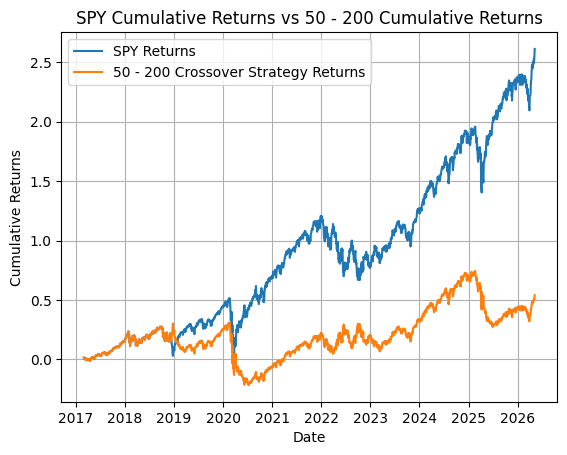

In [95]:
test_and_plot_strategy(df, TICKER, FAST, SLOW, LOOKBACK)